In [1]:
# load data 
from datetime import datetime
import pandas as pd

# load data
data = pd.read_csv("../data/wadi/WADI_attackdata.csv")
labels=[]
train_split = 0.60

for index, row in data.iterrows():
    date_temp=row['Date']
    date_mask="%m/%d/%Y"
    date_obj=datetime.strptime(date_temp, date_mask)
    time_temp=row['Time']
    time_mask="%I:%M:%S.%f %p"
    time_obj=datetime.strptime(time_temp,time_mask)

    if date_obj==datetime.strptime('10/9/2017', '%m/%d/%Y'):
        if time_obj>=datetime.strptime('7:25:00.000 PM', '%I:%M:%S.%f %p') and time_obj<=datetime.strptime('7:50:16.000 PM', '%I:%M:%S.%f %p'):
            labels.append('Attack')
            continue

    if date_obj==datetime.strptime('10/10/2017', '%m/%d/%Y'):
        if time_obj>=datetime.strptime('10:24:10.000 AM', '%I:%M:%S.%f %p') and time_obj<=datetime.strptime('10:34:00.000 AM', '%I:%M:%S.%f %p'):
            labels.append('Attack')
            continue
        elif time_obj>=datetime.strptime('10:55:00.000 AM', '%I:%M:%S.%f %p') and time_obj<=datetime.strptime('11:24:00.000 AM', '%I:%M:%S.%f %p'):
            labels.append('Attack')
            continue
        elif time_obj>=datetime.strptime('11:30:40.000 AM', '%I:%M:%S.%f %p') and time_obj<=datetime.strptime('11:44:50.000 AM', '%I:%M:%S.%f %p'):
            labels.append('Attack')
            continue
        elif time_obj>=datetime.strptime('1:39:30.000 PM', '%I:%M:%S.%f %p') and time_obj<=datetime.strptime('1:50:40.000 PM', '%I:%M:%S.%f %p'):
            labels.append('Attack')
            continue
        elif time_obj>=datetime.strptime('2:48:17.000 PM', '%I:%M:%S.%f %p') and time_obj<=datetime.strptime('2:59:55.000 PM', '%I:%M:%S.%f %p'):
            labels.append('Attack')
            continue
        elif time_obj>=datetime.strptime('5:40:00.000 PM', '%I:%M:%S.%f %p') and time_obj<=datetime.strptime('5:49:40.000 PM', '%I:%M:%S.%f %p'):
            labels.append('Attack')
            continue
        elif time_obj>=datetime.strptime('10:55:00.000 AM', '%I:%M:%S.%f %p') and time_obj<=datetime.strptime('10:56:27.000 AM', '%I:%M:%S.%f %p'):
            labels.append('Attack')
            continue
    
    if date_obj==datetime.strptime('10/11/2017', '%m/%d/%Y'):
        if time_obj>=datetime.strptime('11:17:54.000 AM', '%I:%M:%S.%f %p') and time_obj<=datetime.strptime('11:31:20.000 AM', '%I:%M:%S.%f %p'):
            labels.append('Attack')
            continue
        elif time_obj>=datetime.strptime('11:36:31.000 AM', '%I:%M:%S.%f %p') and time_obj<=datetime.strptime('11:47:00.000 AM', '%I:%M:%S.%f %p'):
            labels.append('Attack')
            continue
        elif time_obj>=datetime.strptime('11:59:00.000 AM', '%I:%M:%S.%f %p') and time_obj<=datetime.strptime('12:05:00.000 PM', '%I:%M:%S.%f %p'):
            labels.append('Attack')
            continue
        elif time_obj>=datetime.strptime('12:07:30.000 PM', '%I:%M:%S.%f %p') and time_obj<=datetime.strptime('12:10:52.000 PM', '%I:%M:%S.%f %p'):
            labels.append('Attack')
            continue
        elif time_obj>=datetime.strptime('12:16:00.000 PM', '%I:%M:%S.%f %p') and time_obj<=datetime.strptime('12:25:36.000 PM', '%I:%M:%S.%f %p'):
            labels.append('Attack')
            continue
        elif time_obj>=datetime.strptime('3:26:30.000 PM', '%I:%M:%S.%f %p') and time_obj<=datetime.strptime('3:37:00.000 PM', '%I:%M:%S.%f %p'):
            labels.append('Attack')
            continue

    labels.append('Normal')

Timestamp = pd.to_datetime(data['Date'] + ' ' + data['Time'])
data=data.drop(data.columns[[0,1,2,50,51,86,87]],axis=1) 
labels = [ int(l!= 'Normal' ) for l in labels]

data = data.astype(float)

n_sensor = len(data.columns)

train_df = data.iloc[:int(train_split*len(data))]
train_label = labels[:int(train_split*len(data))]

val_df = data.iloc[int(0.6*len(data)):int(0.8*len(data))]
val_label = labels[int(0.6*len(data)):int(0.8*len(data))]

test_df = data.iloc[int(0.80*len(data)):]
test_label = labels[int(0.80*len(data)):]

/tmp/ipykernel_3259463/421583230.py:68: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  Timestamp = pd.to_datetime(data['Date'] + ' ' + data['Time'])


In [2]:
# load likelihoods
import json

class NpEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        elif isinstance(obj, np.floating):
            return float(obj)
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        else:
            return super(NpEncoder, self).default(obj)
        
class dotdict(dict):
    """dot.notation access to dictionary attributes"""
    __getattr__ = dict.get
    __setattr__ = dict.__setitem__
    __delattr__ = dict.__delitem__

def load_json(file):
    with open(file) as f:
        obj = json.load(f)
    return obj



def save_json(obj, path):
    with open(path, 'w') as f:
        json.dump(obj, f, cls=NpEncoder, indent=4)

test_results = load_json("../figures/wadi_likelihoods")

likelihoods = test_results["likelihoods"]
timestamp_labels = test_results["labels"]

In [3]:

#print(test_df.columns)

In [4]:
print(Timestamp[147295:147390])

147295   2017-10-11 10:54:55
147296   2017-10-11 10:54:56
147297   2017-10-11 10:54:57
147298   2017-10-11 10:54:58
147299   2017-10-11 10:54:59
                 ...        
147385   2017-10-11 10:56:25
147386   2017-10-11 10:56:26
147387   2017-10-11 10:56:27
147388   2017-10-11 10:56:28
147389   2017-10-11 10:56:29
Length: 95, dtype: datetime64[ns]


In [5]:
print(test_df.loc[163590:163700])
subset_df = test_df.iloc[:, [18, 19, 38]]
# 38

        \\WIN-25J4RO10SBF\LOG_DATA\SUTD_WADI\LOG_DATA\1_AIT_001_PV  \
163590                                            176.142            
163591                                            176.142            
163592                                            176.142            
163593                                            176.142            
163594                                            176.142            
...                                                   ...            
163696                                            176.183            
163697                                            176.183            
163698                                            176.183            
163699                                            176.183            
163700                                            176.183            

        \\WIN-25J4RO10SBF\LOG_DATA\SUTD_WADI\LOG_DATA\1_AIT_002_PV  \
163590                                           0.559483            
163591             

In [6]:

subset_df.columns

Index(['\\WIN-25J4RO10SBF\LOG_DATA\SUTD_WADI\LOG_DATA\1_P_006_STATUS',
       '\\WIN-25J4RO10SBF\LOG_DATA\SUTD_WADI\LOG_DATA\2_DPIT_001_PV',
       '\\WIN-25J4RO10SBF\LOG_DATA\SUTD_WADI\LOG_DATA\2_FIT_001_PV'],
      dtype='object')

<Axes: >

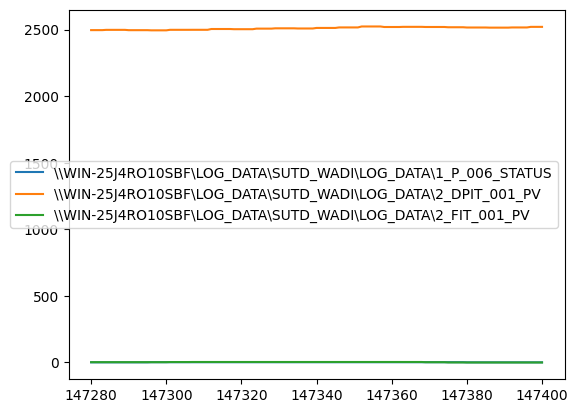

In [7]:
subset_df.loc[147280:147400].plot()

In [8]:
likelihood_df = pd.DataFrame({'values': likelihoods}, index=test_df.index[1:])
likelihood_df = likelihood_df * -1
likelihood_df.head

<bound method NDFrame.head of             values
138241  215.087830
138242  215.042847
138243  215.078629
138244  215.050049
138245 -389.007782
...            ...
172796  237.155579
172797  236.948608
172798  236.969574
172799  236.142792
172800  236.196335

[34560 rows x 1 columns]>

In [9]:
likelihood_df['values'] = (likelihood_df['values'] - likelihood_df['values'].min()) / (likelihood_df['values'].max() - likelihood_df['values'].min())

<Axes: >

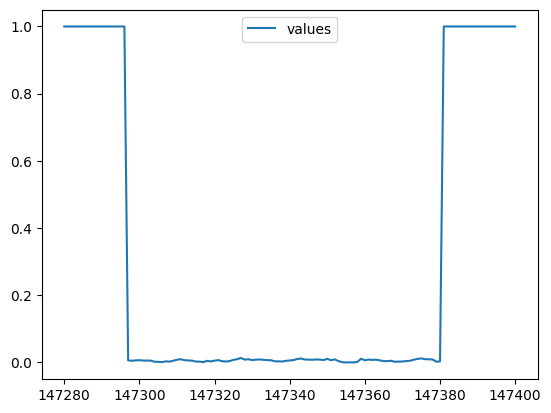

In [10]:
likelihood_df.loc[147280:147400].plot()

In [11]:
subset_df = subset_df.loc[147280:147400]

In [12]:
likelihood_df = likelihood_df.loc[147280:147400]

In [13]:
subset_df["likelihoods"] = likelihood_df.iloc[:, 0]


In [14]:
subset_df.columns = list(subset_df.columns)
subset_df.columns = ['P_006', 'DPIT_001_PV', 'FIC_601_CO', 'likelihoods']

In [15]:
subset_df.columns

Index(['P_006', 'DPIT_001_PV', 'FIC_601_CO', 'likelihoods'], dtype='object')

In [16]:
subset_df["timestamp"] = Timestamp.loc[147280:147400]

In [17]:
subset_df.columns

Index(['P_006', 'DPIT_001_PV', 'FIC_601_CO', 'likelihoods', 'timestamp'], dtype='object')

In [18]:
#subset_df.set_index('timestamp', inplace=True)

In [19]:
subset_df.head

<bound method NDFrame.head of         P_006  DPIT_001_PV  FIC_601_CO  likelihoods           timestamp
147280    1.0      2495.41    2.271270     0.999941 2017-10-11 10:54:40
147281    1.0      2495.41    2.271270     0.999941 2017-10-11 10:54:41
147282    1.0      2495.41    2.271270     0.999941 2017-10-11 10:54:42
147283    1.0      2495.41    2.271270     0.999941 2017-10-11 10:54:43
147284    1.0      2497.38    2.279180     0.999941 2017-10-11 10:54:44
...       ...          ...         ...          ...                 ...
147396    1.0      2515.47    0.000206     0.999942 2017-10-11 10:56:36
147397    1.0      2519.86    0.000051     0.999942 2017-10-11 10:56:37
147398    1.0      2519.86    0.000051     0.999943 2017-10-11 10:56:38
147399    1.0      2519.86    0.000051     0.999943 2017-10-11 10:56:39
147400    1.0      2519.86    0.000051     0.999942 2017-10-11 10:56:40

[121 rows x 5 columns]>

In [20]:
steps = [i for i in range(len(subset_df))]
subset_df["steps"] = steps

In [21]:
subset_df.set_index("steps", inplace=True)

In [22]:
subset_df.head

<bound method NDFrame.head of        P_006  DPIT_001_PV  FIC_601_CO  likelihoods           timestamp
steps                                                                 
0        1.0      2495.41    2.271270     0.999941 2017-10-11 10:54:40
1        1.0      2495.41    2.271270     0.999941 2017-10-11 10:54:41
2        1.0      2495.41    2.271270     0.999941 2017-10-11 10:54:42
3        1.0      2495.41    2.271270     0.999941 2017-10-11 10:54:43
4        1.0      2497.38    2.279180     0.999941 2017-10-11 10:54:44
...      ...          ...         ...          ...                 ...
116      1.0      2515.47    0.000206     0.999942 2017-10-11 10:56:36
117      1.0      2519.86    0.000051     0.999942 2017-10-11 10:56:37
118      1.0      2519.86    0.000051     0.999943 2017-10-11 10:56:38
119      1.0      2519.86    0.000051     0.999943 2017-10-11 10:56:39
120      1.0      2519.86    0.000051     0.999942 2017-10-11 10:56:40

[121 rows x 5 columns]>

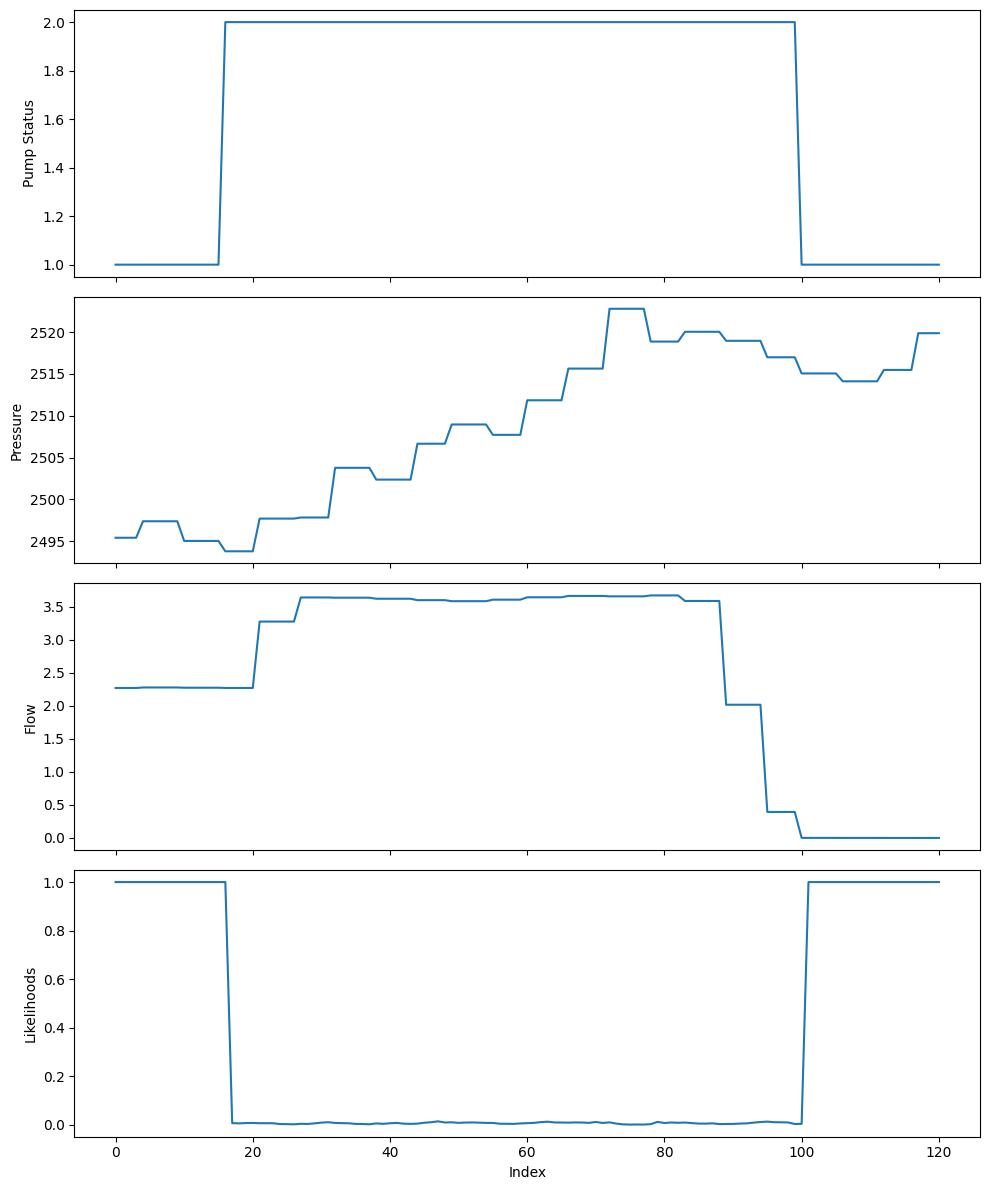

In [32]:
from matplotlib import pyplot as plt

# Plotting
fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)
subset_df.columns = ["Pump Status", "Pressure", "Flow", "Likelihoods", "time"]
for i, column in enumerate(subset_df.columns[:-1]):  # Exclude 'timestamp' and 'steps'
    subset_df[column].plot(ax=axes[i])
    axes[i].set_ylabel(column)
subset_df.to_csv("../figures/wadi_data.csv")
axes[-1].set_xlabel('Index')  # Label for the bottom plot
plt.savefig("../figures/wadi_example.png")
plt.tight_layout()
plt.show()
